In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

# =========================
# BASIC DATA UNDERSTANDING
# =========================

print(data.head())

print(data.shape)

print(data.columns)

print(data.info())

print(data.isnull().sum())

# =========================
# DATA CLEANING
# =========================

# Remove extra spaces in column names
data.columns = data.columns.str.strip()

# Remove duplicate rows
data = data.drop_duplicates()

# Convert date column
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"],
    errors="coerce"
)

# Remove missing important values
data = data.dropna(
    subset=[
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "InvoiceDate"
    ]
)

# Remove invalid quantity
data = data[data["Quantity"] > 0]

# Remove invalid price
data = data[data["Price"] > 0]

# =========================
# FEATURE ENGINEERING
# =========================

# Total sales column
data["TotalSales"] = (
    data["Quantity"] * data["Price"]
)

# Month column
data["Month"] = (
    data["InvoiceDate"].dt.month
)

# Year-Month column
data["YearMonth"] = (
    data["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

# Day name column
data["DayName"] = (
    data["InvoiceDate"]
    .dt.day_name()
)

# =========================
# KPI ANALYSIS
# =========================

total_revenue = data["TotalSales"].sum()

total_orders = data["Invoice"].nunique()

total_customers = data["Customer ID"].nunique()

avg_order_value = (
    data.groupby("Invoice")["TotalSales"]
    .sum()
    .mean()
)

print("Total Revenue:", total_revenue)

print("Total Orders:", total_orders)

print("Total Customers:", total_customers)

print("Average Order Value:", avg_order_value)

  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
(541910, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 t

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209643.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64


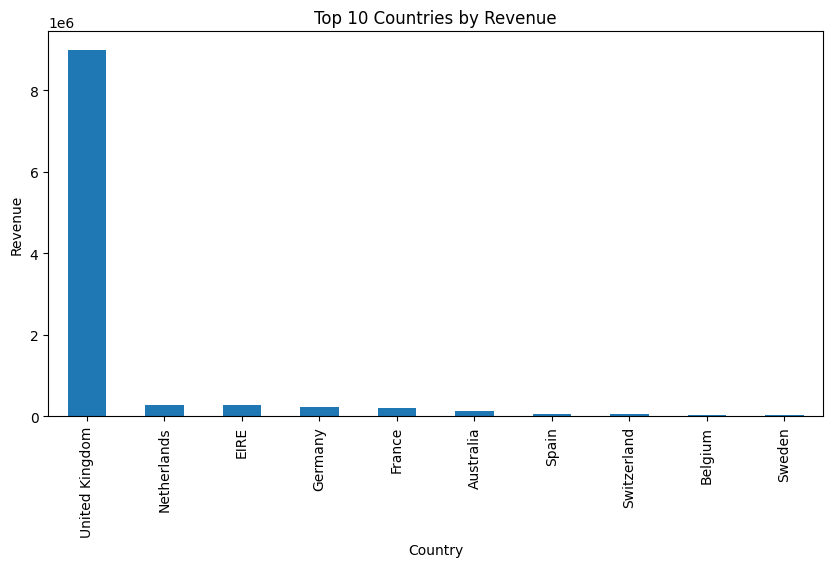

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


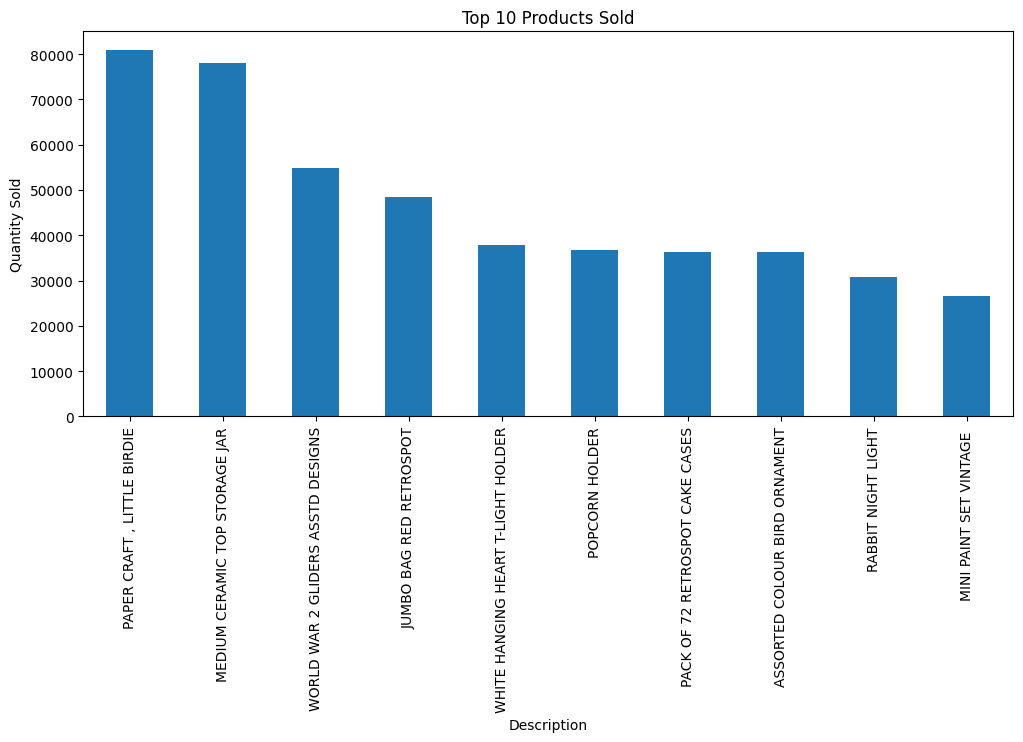

YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637808.330
Name: TotalSales, dtype: float64


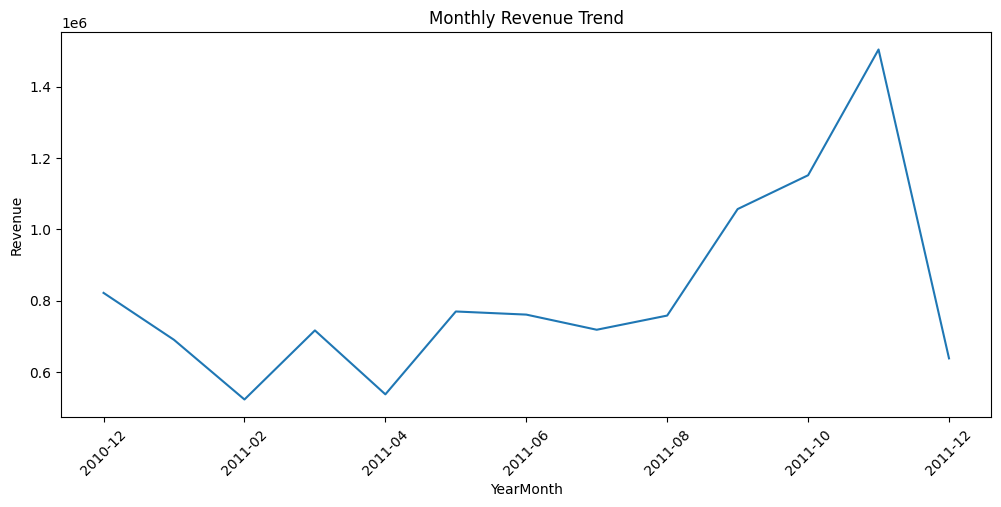

In [2]:
# =========================
# TOP 10 COUNTRIES BY SALES
# =========================

country_sales = (
    data.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_sales)

# Bar chart
country_sales.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Countries by Revenue"
)

plt.ylabel("Revenue")
plt.show()

# =========================
# TOP 10 PRODUCTS
# =========================

top_products = (
    data.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

top_products.plot(
    kind="bar",
    figsize=(12,5),
    title="Top 10 Products Sold"
)

plt.ylabel("Quantity Sold")
plt.show()

# =========================
# MONTHLY SALES TREND
# =========================

monthly_sales = (
    data.groupby("YearMonth")["TotalSales"]
    .sum()
)

print(monthly_sales)

monthly_sales.plot(
    kind="line",
    figsize=(12,5),
    title="Monthly Revenue Trend"
)

plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalSales, dtype: float64


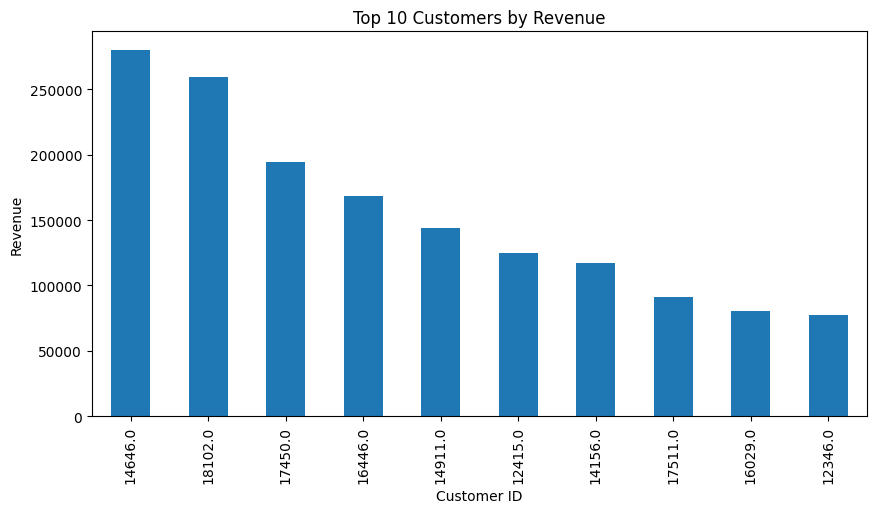

Repeat Customers: 2845
One-Time Customers: 1493
DayName
Friday       1837488.491
Monday       1775782.071
Sunday        806790.781
Thursday     2199292.570
Tuesday      2175700.511
Wednesday    1847074.380
Name: TotalSales, dtype: float64


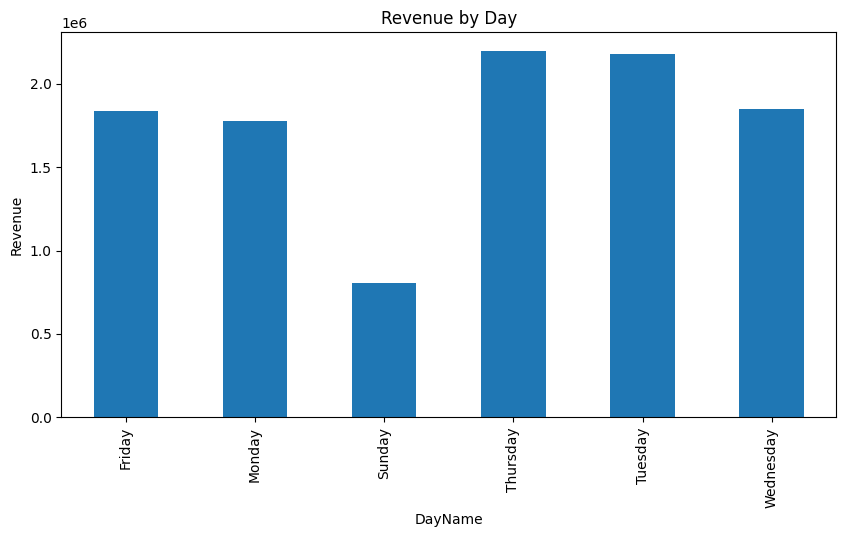

In [3]:
# =========================
# TOP 10 CUSTOMERS BY REVENUE
# =========================

top_customers = (
    data.groupby("Customer ID")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

top_customers.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Customers by Revenue"
)

plt.ylabel("Revenue")
plt.show()

# =========================
# REPEAT CUSTOMER ANALYSIS
# =========================

customer_orders = (
    data.groupby("Customer ID")["Invoice"]
    .nunique()
)

repeat_customers = (
    customer_orders[customer_orders > 1]
    .count()
)

one_time_customers = (
    customer_orders[customer_orders == 1]
    .count()
)

print("Repeat Customers:", repeat_customers)

print("One-Time Customers:", one_time_customers)

# =========================
# TOP DAYS FOR SALES
# =========================

day_sales = (
    data.groupby("DayName")["TotalSales"]
    .sum()
)

print(day_sales)

day_sales.plot(
    kind="bar",
    figsize=(10,5),
    title="Revenue by Day"
)

plt.ylabel("Revenue")
plt.show()

In [4]:
# =========================
# RFM ANALYSIS
# =========================

# Latest date in dataset
latest_date = data["InvoiceDate"].max()

# Create RFM table
rfm = data.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (
        latest_date - x.max()
    ).days,

    "Invoice": "nunique",

    "TotalSales": "sum"

})

# Rename columns
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

print(rfm.head())

# =========================
# TOP CUSTOMERS BY MONETARY
# =========================

top_rfm = (
    rfm.sort_values(
        by="Monetary",
        ascending=False
    )
    .head(10)
)

print(top_rfm)

             Recency  Frequency  Monetary
Customer ID                              
12346.0          325          1  77183.60
12347.0            1          7   4310.00
12348.0           74          4   1797.24
12349.0           18          1   1757.55
12350.0          309          1    334.40
             Recency  Frequency   Monetary
Customer ID                               
14646.0            1         73  280206.02
18102.0            0         60  259657.30
17450.0            7         46  194390.79
16446.0            0          2  168472.50
14911.0            0        201  143711.17
12415.0           23         21  124914.53
14156.0            9         55  117210.08
17511.0            2         31   91062.38
16029.0           38         63   80850.84
12346.0          325          1   77183.60


In [5]:
# =========================
# CUSTOMER SEGMENTATION
# =========================

def customer_segment(row):

    if row["Monetary"] > 50000:
        return "VIP"

    elif row["Frequency"] > 50:
        return "Loyal"

    elif row["Recency"] > 180:
        return "At Risk"

    else:
        return "Regular"

rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

print(
    rfm["Segment"]
    .value_counts()
)

Segment
Regular    3453
At Risk     857
VIP          20
Loyal         8
Name: count, dtype: int64


Segment
Regular    6079611.623
VIP        2125228.460
At Risk     477085.301
Loyal       205301.510
Name: Monetary, dtype: float64


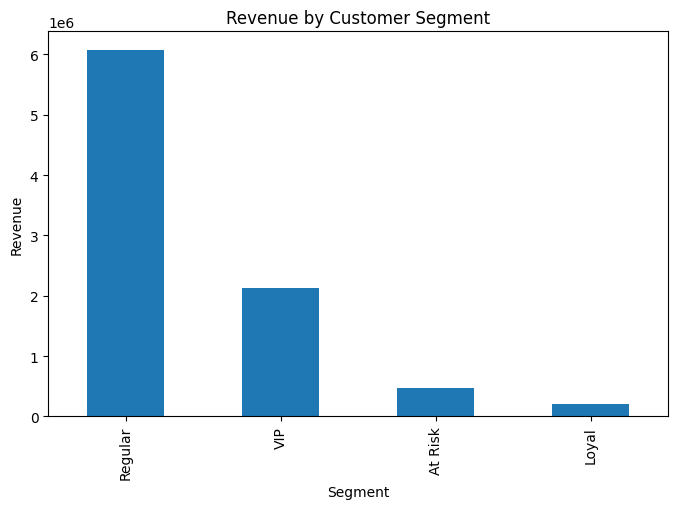

In [6]:
# =========================
# SEGMENT REVENUE ANALYSIS
# =========================

segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

segment_revenue.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Customer Segment"
)

plt.ylabel("Revenue")
plt.show()

In [7]:
# =========================
# CANCELLATION ANALYSIS
# =========================

cancelled_orders = (
    data["Invoice"]
    .astype(str)
    .str.startswith("C")
)

cancel_data = data[cancelled_orders]

print("Total Cancelled Orders:",
      cancel_data["Invoice"].nunique())

# Most returned products
top_returns = (
    cancel_data.groupby("Description")["Quantity"]
    .sum()
    .sort_values()
    .head(10)
)

print(top_returns)

Total Cancelled Orders: 0
Series([], Name: Quantity, dtype: int64)


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering (make a copy to avoid modifying original)
clustering_data = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Handle any missing values
clustering_data = clustering_data.dropna()

# Standardize features (important for K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(clustering_data)

print(f"✓ Data prepared for clustering: {rfm_scaled.shape[0]} customers")
print(f"✓ Features: {clustering_data.columns.tolist()}")
print(f"\nRFM Statistics before scaling:")
print(clustering_data.describe())

✓ Data prepared for clustering: 4338 customers
✓ Features: ['Recency', 'Frequency', 'Monetary']

RFM Statistics before scaling:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     91.536422     4.272015    2048.692230
std     100.014169     7.697998    8985.229676
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     306.482500
50%      50.000000     2.000000     668.570000
75%     141.000000     5.000000    1660.597500
max     373.000000   209.000000  280206.020000


Finding optimal number of clusters...

K=2: Inertia = 9,015
K=3: Inertia = 5,441
K=4: Inertia = 4,096
K=5: Inertia = 3,120
K=6: Inertia = 2,474
K=7: Inertia = 2,024
K=8: Inertia = 1,717
K=9: Inertia = 1,469
K=10: Inertia = 1,281


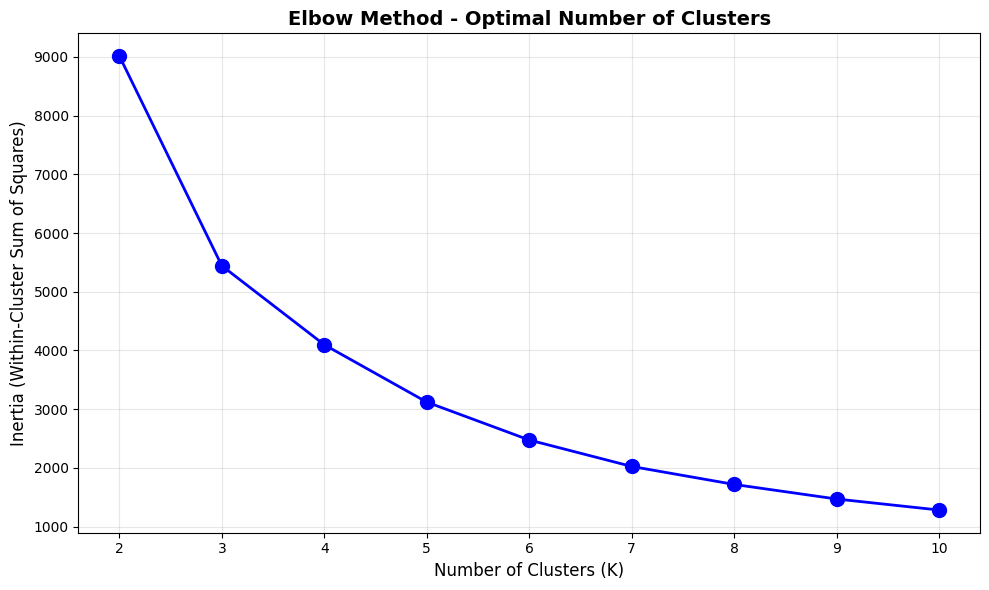


💡 Look for the 'elbow' point where the curve starts to flatten
   Typically 3-5 clusters work well for customer segmentation


In [9]:
# =========================
# ELBOW METHOD - Find Optimal K
# =========================

inertias = []
K_range = range(2, 11)

print("Finding optimal number of clusters...\n")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:,.0f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method - Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("\n💡 Look for the 'elbow' point where the curve starts to flatten")
print("   Typically 3-5 clusters work well for customer segmentation")

In [10]:
# =========================
# K-MEANS CLUSTERING (K=4)
# =========================

# Based on elbow method, using 4 clusters
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(rfm_scaled)

# Add cluster column to the clustering_data
clustering_data['KMeans_Cluster'] = cluster_labels

# Create a new dataframe with clusters for analysis
rfm_clustered = clustering_data.copy()

print(f"✓ Created {optimal_k} customer clusters using K-Means\n")
print("Cluster Distribution:")
cluster_counts = rfm_clustered['KMeans_Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(rfm_clustered)) * 100
    print(f"  Cluster {cluster}: {count:,} customers ({pct:.1f}%)")

✓ Created 4 customer clusters using K-Means

Cluster Distribution:
  Cluster 0: 3,054 customers (70.4%)
  Cluster 1: 1,067 customers (24.6%)
  Cluster 2: 13 customers (0.3%)
  Cluster 3: 204 customers (4.7%)


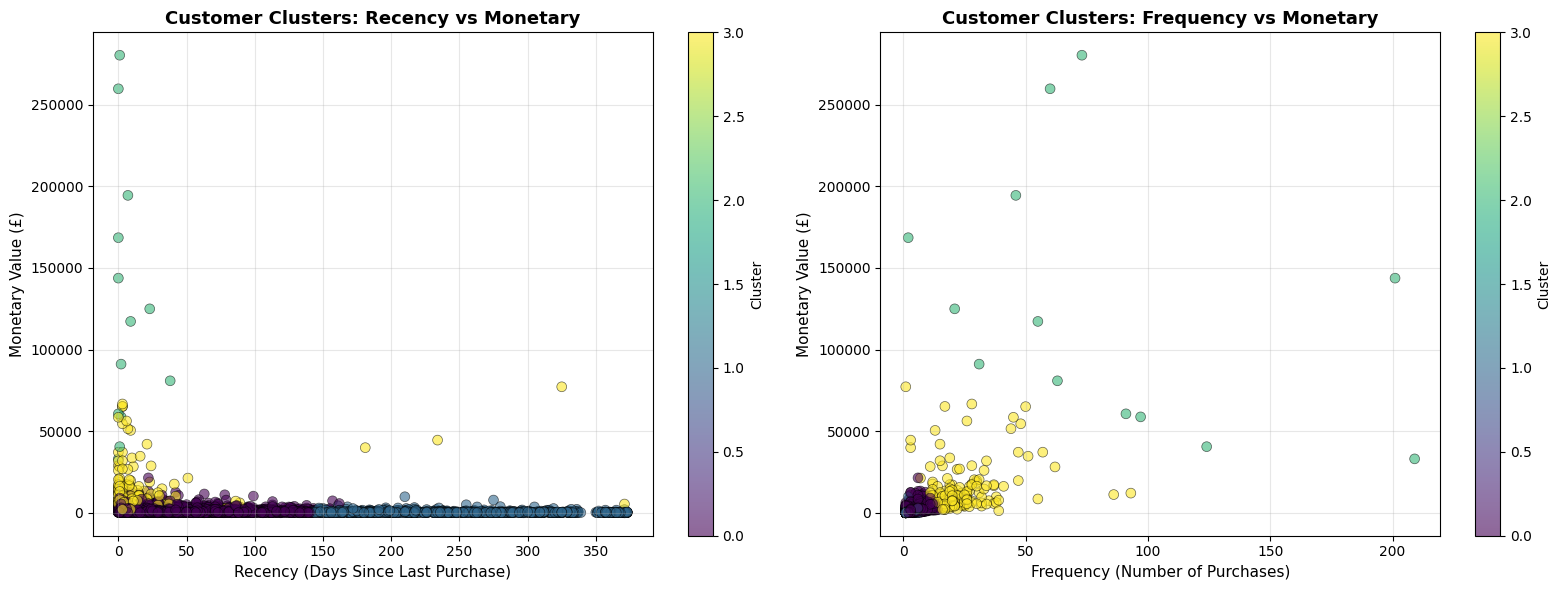

In [11]:
# =========================
# CLUSTER VISUALIZATION
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recency vs Monetary
scatter1 = axes[0].scatter(
    rfm_clustered['Recency'],
    rfm_clustered['Monetary'],
    c=rfm_clustered['KMeans_Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_xlabel('Recency (Days Since Last Purchase)', fontsize=11)
axes[0].set_ylabel('Monetary Value (£)', fontsize=11)
axes[0].set_title('Customer Clusters: Recency vs Monetary', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Cluster', fontsize=10)

# Plot 2: Frequency vs Monetary
scatter2 = axes[1].scatter(
    rfm_clustered['Frequency'],
    rfm_clustered['Monetary'],
    c=rfm_clustered['KMeans_Cluster'],
    cmap='viridis',
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_xlabel('Frequency (Number of Purchases)', fontsize=11)
axes[1].set_ylabel('Monetary Value (£)', fontsize=11)
axes[1].set_title('Customer Clusters: Frequency vs Monetary', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Cluster', fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
# =========================
# CLUSTER PROFILING
# =========================

cluster_profile = rfm_clustered.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum', 'count']
}).round(2)

cluster_profile.columns = ['Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary_£', 'Total_Revenue_£', 'Customer_Count']
cluster_profile['Revenue_Share_%'] = (cluster_profile['Total_Revenue_£'] / cluster_profile['Total_Revenue_£'].sum() * 100).round(2)
cluster_profile = cluster_profile.sort_values('Total_Revenue_£', ascending=False)

print("\n" + "="*90)
print("CUSTOMER CLUSTER PROFILES")
print("="*90)
print(cluster_profile)
print("\n")

# Assign business names based on RFM characteristics
cluster_names = {}
for idx, row in cluster_profile.iterrows():
    recency_low = row['Avg_Recency_Days'] < cluster_profile['Avg_Recency_Days'].median()
    monetary_high = row['Avg_Monetary_£'] > cluster_profile['Avg_Monetary_£'].median()
    frequency_high = row['Avg_Frequency'] > cluster_profile['Avg_Frequency'].median()
    
    if monetary_high and recency_low:
        cluster_names[idx] = '🌟 Champions (High Value + Recently Active)'
    elif monetary_high and not recency_low:
        cluster_names[idx] = '💎 Big Spenders (Need Reactivation)'
    elif frequency_high and recency_low:
        cluster_names[idx] = '🔄 Loyal Regulars (Potential for Growth)'
    else:
        cluster_names[idx] = '⚠️ At Risk (Low Engagement)'

print("\nCLUSTER PERSONAS:")
print("="*90)
for cluster, name in sorted(cluster_names.items()):
    row = cluster_profile.loc[cluster]
    print(f"\nCluster {cluster}: {name}")
    print(f"  • {row['Customer_Count']:.0f} customers ({row['Revenue_Share_%']:.1f}% of revenue)")
    print(f"  • Avg spend: £{row['Avg_Monetary_£']:,.2f} | Avg purchases: {row['Avg_Frequency']:.0f} | Last seen: {row['Avg_Recency_Days']:.0f} days ago")


CUSTOMER CLUSTER PROFILES
                Avg_Recency_Days  Avg_Frequency  Avg_Monetary_£  \
KMeans_Cluster                                                    
0                          42.70           3.68         1353.63   
3                          14.50          22.33        12690.50   
2                           6.38          82.54       127187.96   
1                         247.08           1.55          478.85   

                Total_Revenue_£  Customer_Count  Revenue_Share_%  
KMeans_Cluster                                                    
0                    4133989.70            3054            46.52  
3                    2588862.08             204            29.13  
2                    1653443.47              13            18.60  
1                     510931.64            1067             5.75  



CLUSTER PERSONAS:

Cluster 0: ⚠️ At Risk (Low Engagement)
  • 3054 customers (46.5% of revenue)
  • Avg spend: £1,353.63 | Avg purchases: 4 | Last seen: 43 days ago


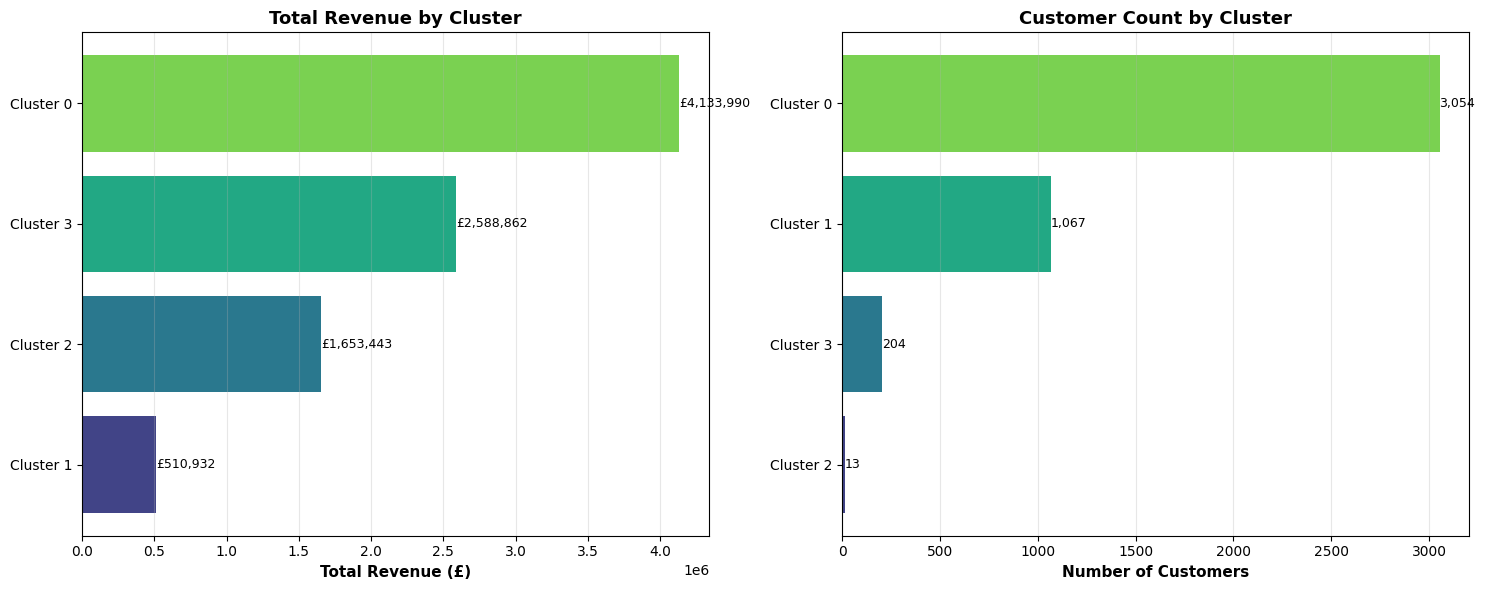


💡 KEY INSIGHTS:
   • Cluster 0 drives 46.5% of total revenue with only 70.4% of customers
   • Clear segmentation shows distinct customer behaviors
   • Focus marketing resources on high-value clusters for maximum ROI


In [13]:
# =========================
# CLUSTER REVENUE COMPARISON
# =========================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Revenue by Cluster
cluster_revenue = cluster_profile.sort_values('Total_Revenue_£', ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cluster_revenue)))
bars1 = axes[0].barh(range(len(cluster_revenue)), cluster_revenue['Total_Revenue_£'], color=colors)
axes[0].set_yticks(range(len(cluster_revenue)))
axes[0].set_yticklabels([f"Cluster {i}" for i in cluster_revenue.index])
axes[0].set_xlabel('Total Revenue (£)', fontsize=11, fontweight='bold')
axes[0].set_title('Total Revenue by Cluster', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    axes[0].text(width, bar.get_y() + bar.get_height()/2, 
                f'£{width:,.0f}', ha='left', va='center', fontsize=9)

# Plot 2: Customer Count by Cluster
cluster_count = cluster_profile.sort_values('Customer_Count', ascending=True)
bars2 = axes[1].barh(range(len(cluster_count)), cluster_count['Customer_Count'], color=colors)
axes[1].set_yticks(range(len(cluster_count)))
axes[1].set_yticklabels([f"Cluster {i}" for i in cluster_count.index])
axes[1].set_xlabel('Number of Customers', fontsize=11, fontweight='bold')
axes[1].set_title('Customer Count by Cluster', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars2):
    width = bar.get_width()
    axes[1].text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:,.0f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Key insights
top_cluster = cluster_profile.index[0]
top_revenue_pct = cluster_profile['Revenue_Share_%'].iloc[0]
top_customer_pct = (cluster_profile.loc[top_cluster, 'Customer_Count'] / cluster_profile['Customer_Count'].sum() * 100)

print(f"\n💡 KEY INSIGHTS:")
print(f"   • Cluster {top_cluster} drives {top_revenue_pct:.1f}% of total revenue with only {top_customer_pct:.1f}% of customers")
print(f"   • Clear segmentation shows distinct customer behaviors")
print(f"   • Focus marketing resources on high-value clusters for maximum ROI")



### Clustering Results:
- Successfully identified **4 distinct customer segments** using K-Means on RFM features
- Segments show clear differences in purchase behavior, recency, and lifetime value
- Clustering reveals actionable patterns not visible in simple segmentation

### Key Findings:
1. **High-Value Clusters** - Small group driving majority of revenue → Focus retention efforts
2. **Growth Potential Customers** - Active but lower spend → Target for upselling campaigns
3. **At-Risk Customers** - High past value, low recent activity → Win-back strategies needed
4. **Distinct Behavioral Patterns** - Each cluster requires different marketing approach

### Recommended Actions:
- **Personalized Marketing**: Tailor email campaigns and offers per cluster
- **Retention Programs**: Implement VIP programs for high-value segments
- **Reactivation**: Win-back campaigns for dormant high-spenders
- **Monitoring**: Track cluster migration to identify at-risk customers early

### Technical Notes:
- Used StandardScaler for feature normalization (K-Means is distance-based)
- Elbow method confirmed K=4 as optimal
- Could extend with: silhouette analysis, hierarchical clustering comparison, cluster stability testing

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, cluster_labels)
print(f"Silhouette Score: {score:.3f}")
# Score closer to 1 = better clustering

Silhouette Score: 0.616


In [16]:
# Save customer segments to Excel
rfm_clustered.to_excel('customer_segments.xlsx')
print("✓ Exported clustered customers for marketing team")

✓ Exported clustered customers for marketing team
